In [86]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from GB84 import variables, rho_m, v,cloud_heights, h_out, phi, f, non_dim_numbers
from kalman_filter_2 import kalman_filter as kf
from sklearn.metrics import mean_squared_error
from scipy.optimize import fsolve

## Testing the model

In [4]:
#put the time interval you want to test inside "slice_str"

slice_str = "2024-07-05 19:59:00, 2024-07-07 19:59:00"
slice_tuple = tuple(slice_str.split(", "))


#### Surface Measurements

In [5]:
# Continuous observations from the CESAR network, Cabauw, surface meteo
measurements = xr.open_mfdataset(r'C:\Users\chari\Home\TU Delft\TU-Delft\thesis\rainmodel_conc\cesar_surface_meteo_lc1_t10_v1.0_202407.nc')

#### Radiometer LWC 

Radiometer measurements to extract the liquid water path to be used as the initial state estimate at the initialization of the model

In [6]:
cabaw = xr.open_mfdataset(r'C:\Users\chari\Home\TU Delft\TU-Delft\thesis\rainmodel_conc\data\Cabaw_radiometer\*.nc')
reference_date = np.datetime64("2024-07-01")

# Convert minutes into datetime
#datetime_values = reference_date + measurements.time.astype("timedelta64[m]")
#measurements['time'] = datetime_values

july = cabaw.sel(time=slice(*slice_tuple))

In [73]:
july.lwp.values

array([0.04710745, 0.04931879, 0.0471085 , ..., 0.09072326, 0.08975485,
       0.08900185], dtype=float32)

In [7]:
#var = ['temperature','pressure','humidity','rain_rate']
var = ['TA002','P0','TD002','RH002'] #temperature, pressure, dew point temperature, relative humidity at 2m height
measurements = measurements[var]
measurements = measurements.dropna(dim='time',how='any')
measurements_used = measurements.sel(time=slice(*slice_tuple))

#### Parsivel data

In [8]:
#disdorometer data to be used as reference for rain rate for comparison, as well as for the Kalman filter updates

parsivel_1 = xr.open_dataset(r'C:\Users\chari\Home\TU Delft\TU-Delft\thesis\rainmodel_conc\data\Cabaw_parsivel\PAR001_Cabauw_202407.nc')
reference_date = np.datetime64("1970-01-01")

# Convert minutes into datetime
datetime_values = reference_date + parsivel_1.epoch_time.astype("timedelta64[s]")
parsivel_1['time'] = datetime_values

In [9]:
rain_rate = parsivel_1.rainfall_rate_32bit.sel(time=measurements.time,method='nearest')

In [10]:
#kf_measurements = rain_rate.isel(time=slice(None, None, 6))
kf_measurements_used = rain_rate.sel(time=slice(*slice_tuple))

#inputs

#temperature on the ground
T_surf_C = measurements_used['temperature'].values #[C]
T_surf = T_surf_C + 273.15    # [K]

#pressure
p_surf = measurements_used['pressure'].values*100  #[Pa]

#dew point temperature
RH = measurements_used['humidity'].values
alpha_T = 17.27*T_surf_C/(T_surf_C + 237.7) + np.log(RH/100) #from http://dx.doi.org/10.31648/ts.5425
T_d_arr = 237.7*alpha_T/(17.27 - alpha_T) + 273.15      #[K]

#state
X = np.zeros(len(T_surf))
X[0] = july.lwp[0]   #initial state in kg/m2
Sigma = np.zeros(len(T_surf))
Sigma[0] = 5 #initial state covariance in kg/m2

#timestep
dt= 600      #timestep in s

In [11]:
#model inputs

#temperature on the ground
T_surf = measurements_used['TA002'].values #[K]


#pressure
p_surf = measurements_used['P0'].values*100  #[Pa]

#dew point temperature
T_d_arr = measurements_used['TD002'].values     #[K]

#state
X = np.zeros(len(T_surf))
X[0] = july.lwp[0]   #initial state in kg/m2
#X = july.lwp.sel(time=measurements_used.time,method='nearest').values
Sigma = np.zeros(len(T_surf))
Sigma[0] = 1 #initial state covariance in kg/m2

#timestep
dt= 600      #timestep in s

In [12]:
# testing if the dew point temperature is calculated correctly from the relative humidity
RH = measurements_used['RH002'].values
T_surf_C =T_surf - 273.15
alpha_T = 17.27*T_surf_C/(T_surf_C + 237.7) + np.log(RH/100) #from http://dx.doi.org/10.31648/ts.5425
T_d_arr_2 = 237.7*alpha_T/(17.27 - alpha_T) + 273.15      #[K]

#### Model Runs

In [13]:
#empty arrays for storing model outputs

P = np.zeros(len(T_surf))  #precipitation
P_0 = np.zeros(len(T_surf)) #constant state precipitation
f_arr = np.zeros(len(T_surf)) #moisture input
h_arr = np.zeros(len(T_surf))   #moisture outflow
j = 0                       #initial kf index
Q = 0.32

In [14]:
#loop for finding the precipitation given the T_0 and p

for i in range(0,len(T_surf)):

    #inputs
    T_0 = T_surf[i]
    p_0 = p_surf[i]
    T_d = T_d_arr[i]

    #meteorological variables
    p_s,T_s,p_t, T_m, T_t,T_s_up, p_s_up,a = variables(T_0, T_d, p_0, obs=False).run()
    rho = rho_m(T_s,T_t,p_s,p_t)    #average density in the cloud layer
    v_updr = v(T_m,T_s_up)           #updraft velocity
    Z_c,Z_b = cloud_heights(T_s,T_t,T_0,p_s,p_t,p_0)    #cloud heights

    # in cloud fluxes
    f_arr[i] = f(T_d,p_0,p_t,T_t,rho,v_updr)    #moisture input
    h_arr[i] = h_out(v_updr,Z_c).run()[2]       #moisture outflow
    O_b,O_t,h_v = h_out(v_updr,Z_c).run()   #bottom, top and total outflow


    #precipitation in kg/m2/s
    P_0[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*3  #constant state precipitation
    P[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*X[i] #*X[i] if we are using the updated state
    #print(phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*3600)
    #state without Kalman filter
    
    #print(T_s_up,T_m)

       
    if i<(len(T_surf)-1):
            print(np.trapz([h_arr[j:i+1]*X[j:i+1]], dx=dt))
            X[i+1] = max(0,X[i] + (np.trapz([f_arr[j:i+1]], dx=dt)) - np.trapz([h_arr[j:i+1]*X[j:i+1]], dx=dt))
            Sigma[i+1] = Sigma[i] + 2*np.trapz([h_arr[j:i+1]*Sigma[j:i+1]], dx=dt) + Q*dt*(i - j)
    if i>=0:
        #state update with Kalman filter when measurements are available

        if (((i%120)==0)&(i>0)): #every 3 hours (10 min intervals - 6*3=18)

            # we assume that we receive a precipitation update every 60mins
            j = i
            print(j)
            
            phi_kf = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()
            h_kf = h_out(v_updr,Z_c).run()[2]
            f_kf = f(T_d,p_0,p_t,T_t,rho,v_updr)
            
            kalman_f = kf(X[i], Sigma[i], dt,h_kf,phi_kf,f_kf,kf_measurements_used[j].values) 
            X[i+1],Sigma[i+1],X_apr = kalman_f.update()




[0.]
[0.00473251]
[0.0122676]
[0.02806741]
[0.05709574]
[0.10321606]
[0.16897455]
[0.25530907]
[0.36077402]
[0.48172568]
[0.61317318]
[0.74876856]
[0.88087385]
[1.00188467]
[1.1052915]
[1.18603861]
[1.24098432]
[1.26935271]
[1.27695441]
[1.27695441]
[1.27695441]
[1.27695441]
[1.27766238]
[1.2830007]
[1.29913277]
[1.33133306]
[1.38349147]
[1.4575534]
[1.55338346]
[1.66864692]
[1.79873642]
[1.93726589]
[2.07640144]
[2.20775066]
[2.32331926]
[2.41607884]
[2.48059058]
[2.51384775]
[2.52247331]
[2.52247331]
[2.52247331]
[2.52247331]
[2.52247331]
[2.52247331]
[2.52247331]
[2.52411509]
[2.53171215]
[2.5504475]
[2.58492924]
[2.63856723]
[2.71305361]
[2.80816549]
[2.92177356]
[3.04950929]
[3.18517651]
[3.32176799]
[3.45198972]
[3.56879737]
[3.66612637]
[3.7389737]
[3.79137051]
[3.8401805]
[3.90651777]
[4.01087282]
[4.169103]
[4.39353762]
[4.69063232]
[5.06280739]
[5.50234953]
[5.9783409]
[6.46912924]
[6.94751352]
[7.36544104]
[7.68529066]
[7.87662069]
[7.93654969]
[7.93654969]
[7.93654969]
[7.9

In [89]:
epsilon = 0.622  # unitless
A = 2.5e6  # (J/kg)
B = 2.38e3  # (J/(kg K))
A_1 = 8e-4  # (kg/(m·s²·K^3.5))
A_2 = 2.11e-5  # (m²/s) 
T_star = 273.15  # (K)
p_star = 101325  # (kg/(m·s²))
p_n = 1e5  # nominal pressure - (kg/(m·s²))
g = 9.80  # (m/s²)
R = 287  # (J/(kg·K))
R_v = 461  # (J/(kg·K))
c_p = 1004  # (J/(kg·K))
p_l = 2e4  # lowest possible cloud top pressure - (kg/(m·s²))
alpha_rain = 3500  # (1/s) for rain
alpha_snow = 1500  # (1/s) for snow
c1_rain = 7e5  # (kg/(m³·s)) for rain
c1_snow = 1.4e5  # (kg/(m³·s)) for snow
C_1 = c1_rain
alpha = alpha_rain



# In[61]:


# storm invariant parameters from Georgakakos 1986
epsilon_1 = 1.65e-3*10  # unitless
epsilon_2 = 5e4  # highest possible cloud top pressure - (kg/(m/s²))
epsilon_3 = 1  # (s/m)
epsilon_4 = 5.5e-5  # nominal hydrometeor diameter - (m)
gamma = 1  # unitless
beta = 0.1  # unitless
m = 0  # unitless
delta = 1/3*(1/gamma + 1/gamma**2 + 1/gamma**3)


D_AB = A_2*(T_0/T_star)**1.94*(p_star/p_0)
def e_s(T):
    #saturation vapor pressure
    return A_1*(T - 223.15)**3.5
def equation_Tw(self, T):
        #wet bulb temperature
         return T + L(self.T_0)/c_p*(epsilon*A_1*(T - 223.15)**3.5/self.p_0 - w(self.T_d,self.p_0)) - self.T_0
     
def solve_Tw():
        #numerical solution of wet bulb temperature
         T_w_initial = 290
         return fsolve(equation_Tw, T_w_initial)
T_w = solve_Tw()
#critical diameter for evaporation
D_c = (1/C_1*4*D_AB/R_v*Z_b*(e_s(T_w)/T_w - e_s(T_d)/T_0))**(1/3)

TypeError: equation_Tw() missing 1 required positional argument: 'T'

### Plots and results

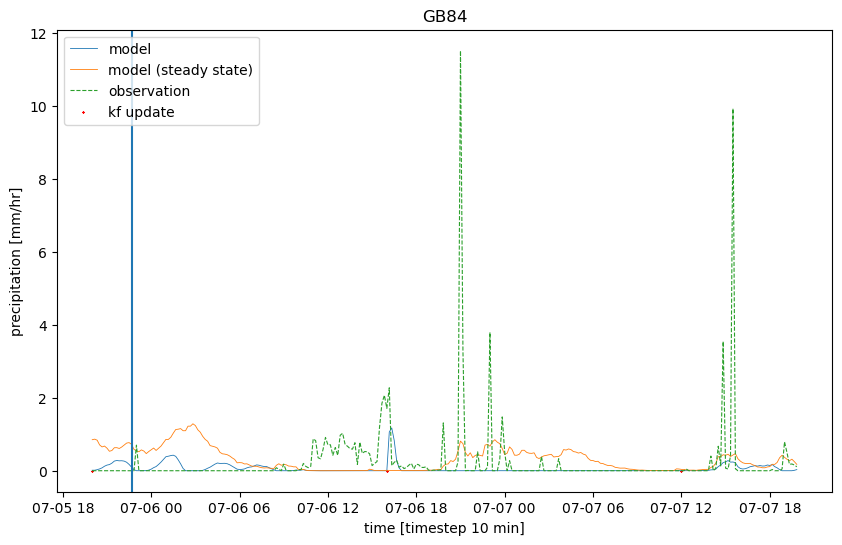

In [15]:
plt.figure(figsize=(10,6))
t_step = np.linspace(0,len(P),len(P))

plt.plot(measurements_used.time,P*3600,label='model',linewidth=0.6)   #P [kg/m2/s] = P/1000kg/m3 = P/1000 m/s = P* 3600 [mm/hr]
plt.plot(measurements_used.time,P_0*3600,label='model (steady state)',linewidth=0.6)
plt.plot(measurements_used.time,rain_rate.sel(time=slice(*slice_tuple)),label='observation',linewidth=0.8,linestyle='--')
plt.scatter(measurements_used.time[0::120],np.zeros((len(kf_measurements_used[0::120]))),label='kf update',marker='x',s=0.6,color='red')

plt.xlabel('time [timestep 10 min]')
plt.title('GB84')
plt.ylabel('precipitation [mm/hr]')
plt.axvline(measurements_used.time[16].values)
plt.legend()
plt.show()


In [84]:
phi(T_0, p_0, T_d, Z_b, Z_c,v_updr*100).calculate_phi()*3600

array([0.00226033])

In [82]:
v_updr

0.06898837966710011

In [17]:
measurements_used.time[0::18]

<xarray.DataArray 'time' (time: 16)> Size: 128B
array(['2024-07-05T20:00:00.000000000', '2024-07-05T23:00:00.000000000',
       '2024-07-06T02:00:00.000000000', '2024-07-06T05:00:00.000000000',
       '2024-07-06T08:00:00.000000000', '2024-07-06T11:00:00.000000000',
       '2024-07-06T14:00:00.000000000', '2024-07-06T17:00:00.000000000',
       '2024-07-06T20:00:00.000000000', '2024-07-06T23:00:00.000000000',
       '2024-07-07T02:00:00.000000000', '2024-07-07T05:00:00.000000000',
       '2024-07-07T08:00:00.000000000', '2024-07-07T11:00:00.000000000',
       '2024-07-07T14:00:00.000000000', '2024-07-07T17:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 128B 2024-07-05T20:00:00 ... 2024-07-07T17...
Attributes:
    long_name:      hours since 2024-07-01 00:00:00 (UTC)
    standard_name:  time
    axis:           T
    bounds:         time_bnds

In [74]:
X

array([4.71074507e-02, 4.71074507e-02, 1.02801602e-01, 2.10583091e-01,
       3.63364902e-01, 5.48550332e-01, 7.50251164e-01, 9.49115321e-01,
       1.12397472e+00, 1.25713939e+00, 1.33188400e+00, 1.33540599e+00,
       1.26324811e+00, 1.12052796e+00, 9.19156549e-01, 6.75134503e-01,
       4.09749918e-01, 1.49314625e-01, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 1.38244123e-02, 9.05960626e-02,
       2.25391055e-01, 4.06236377e-01, 6.16341755e-01, 8.36535269e-01,
       1.04595179e+00, 1.22150352e+00, 1.34225289e+00, 1.39071134e+00,
       1.35740341e+00, 1.24119095e+00, 1.04765711e+00, 7.89794557e-01,
       4.88243569e-01, 1.70763503e-01, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 3.24206163e-02, 1.17357025e-01, 2.51565865e-01,
       4.25557815e-01, 6.25586475e-01, 8.32802566e-01, 1.02649524e+00,
       1.18609517e+00, 1.29363550e+00, 1.33737973e+00, 1.30962160e+00,
      

In [19]:
#error metrics
rmse = mean_squared_error(rain_rate.sel(time=slice(*slice_tuple)),P*3600)
print('The RMSE is',rmse)

The RMSE is 1.035888661916224


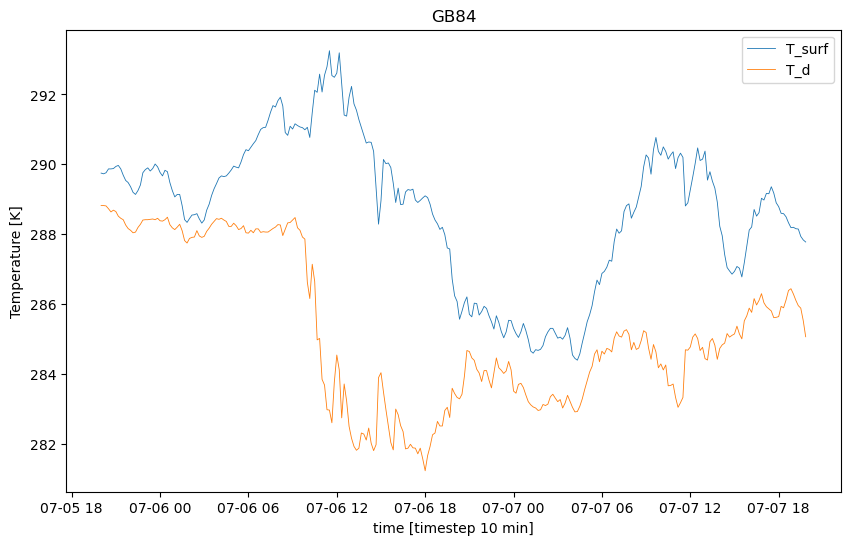

In [20]:
plt.figure(figsize=(10,6))
plt.plot(measurements_used.time,T_surf,label='T_surf',linewidth=0.6)
plt.plot(measurements_used.time,T_d_arr,label='T_d',linewidth=0.6)
plt.xlabel('time [timestep 10 min]')
plt.title('GB84')
plt.ylabel('Temperature [K]')
plt.legend()
plt.show()

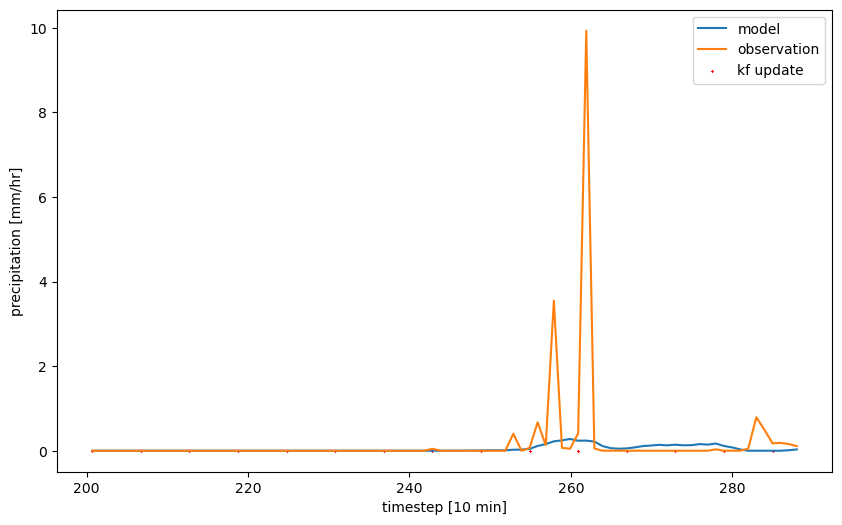

In [21]:
#zooming when no rain is observed
plt.figure(figsize=(10,6))
t_step = np.linspace(0,len(P),len(P))
plt.plot(t_step[200:400],P[200:400]*3600,label='model')
plt.plot(t_step[200:400],rain_rate.sel(time=slice(*slice_tuple))[200:400],label='observation')
plt.scatter(t_step[200:400:6],np.zeros((len(kf_measurements_used[200:400:6]))),label='kf update',marker='x',s=0.6,color='red')
plt.legend()
plt.xlabel('timestep [10 min]')
plt.ylabel('precipitation [mm/hr]')
plt.show()


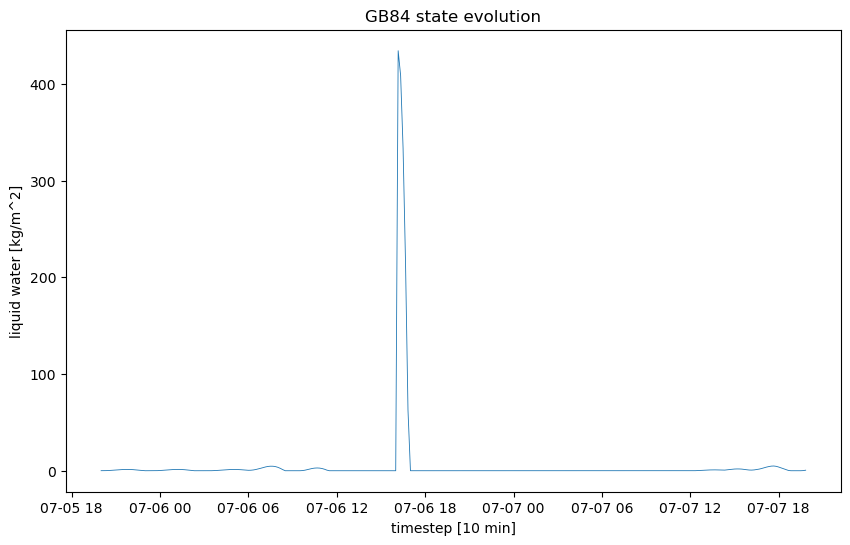

In [22]:
#state evolution


plt.figure(figsize=(10,6))
plt.title('GB84 state evolution')
plt.plot(measurements_used.time,X,linewidth=0.6)
#plt.plot(july.time,july.lwp)
plt.xlabel('timestep [10 min]')
plt.ylabel('liquid water [kg/m^2]')
plt.show()

Text(0, 0.5, 'average hourly precipitation (mm/hr)')

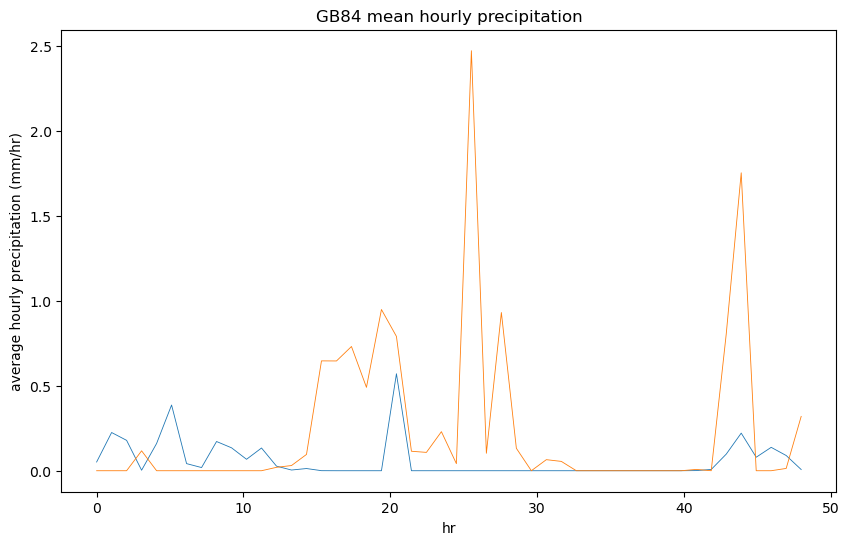

In [23]:
#average hourly precipitation

Pmeas = rain_rate.sel(time=slice(*slice_tuple))
averages_P = [np.mean(P[i:i+6]) for i in range(0, len(P), 6)]
averages_Pmeas=[np.mean(Pmeas[i:i+6]) for i in range(0, len(P), 6)]
t_hr = np.linspace(0,len(averages_P),len(averages_P))

plt.figure(figsize=(10,6))
plt.title('GB84 mean hourly precipitation')
plt.plot(t_hr,np.array(averages_P)*3600,label='model (Kf)',linewidth=0.6)   #P [kg/m2/s] = P/1000kg/m3 = P/1000 m/s = P* 3600 [mm/hr]
plt.plot(t_hr,averages_Pmeas,label='observation',linewidth=0.6)
plt.xlabel('hr')
plt.ylabel('average hourly precipitation (mm/hr)')

#### Runs for physical analysis

In [24]:
#empty arrays for model outputs

v_arr = np.zeros(len(T_surf))
O_b_arr = np.zeros(len(T_surf))
O_h_arr = np.zeros(len(T_surf))
I_arr = np.zeros(len(T_surf))
Z_b_arr = np.zeros(len(T_surf))
Z_c_arr = np.zeros(len(T_surf))
T_m_arr = np.zeros(len(T_surf))
T_t_arr = np.zeros(len(T_surf))
Theta_e_arr = np.zeros(len(T_surf))
p_t_arr = np.zeros(len(T_surf))

In [25]:

for i in range(0,len(T_surf)):
    #inputs
    T_0 = T_surf[i]
    p_0 = p_surf[i]
    T_d = T_d_arr[i]

    #meteorological variables
    p_s,T_s,p_t, T_m, T_t,T_s_up, p_s_up,Theta_e = variables(T_0, T_d, p_0, obs=False).run()
    Theta_e_arr[i] = Theta_e
    p_t_arr[i] = p_t
    T_t_arr[i] = T_t
    T_m_arr[i] = T_m
    print(p_t_arr[i])
    rho = rho_m(T_s,T_t,p_s,p_t)
    v_updr = v(T_m,T_s_up)
    v_arr[i] = v_updr
    Z_c,Z_b = cloud_heights(T_s,T_t,T_0,p_s,p_t,p_0)
    Z_c_arr[i] = Z_c
    Z_b_arr[i] = Z_b
    O_b,O_t,h_v = h_out(v_updr,Z_c).run()   #outflows and sources of water
    #print(non_dim_numbers(v_updr)[1])
    O_b_arr[i] = O_b*X[i]*non_dim_numbers(v_updr)[0]/Z_c
    O_h_arr[i] = O_t*X[i]*non_dim_numbers(v_updr)[0]/Z_c/10
    I_arr[i] = f(T_d,p_0,p_t,T_t,rho,v_updr)
     


49657.95065688852
49662.24678252978
49666.58761327909
49646.364232517495
49655.54263361199
49632.00954532326
49651.916559820485
49634.51374505631
49632.60567393487
49648.91029336977
49657.83694863647
49649.34115682653
49637.86043571046
49639.97350042507
49656.901839203776
49657.87271598975
49652.90346536532
49647.89079770318
49640.49460020647
49643.65745952875
49632.860089648544
49640.243772851296
49623.820354342366
49643.41778158895
49638.5814076343
49652.21036874941
49629.721835182834
49641.47468060785
49644.863128621524
49657.21176017555
49675.66458686165
49670.09480524907
49683.76962606692
49695.68350434679
49712.93672273236
49718.098518710336
49719.19024083187
49709.573187754184
49710.61049357217
49719.596864865765
49725.27427009801
49728.9928418217
49722.04111939062
49717.57613337937
49700.46117788752
49677.8107629911
49669.66899379012
49659.238124125724
49645.54266790307
49654.085975599606
49643.1364128669
49651.59401904401
49632.618176657095
49620.031369906384
49630.01764389242

In [26]:
import numpy as np
from scipy.optimize import fsolve,least_squares
import xarray as xr
from sympy import Symbol, Eq,exp, sqrt, lambdify
from sympy import exp, sqrt, Max
import matplotlib.pyplot as plt
from kalman_filter import kalman_filter as kf

# Constants (taken from A Generalized Stochastic Hydrometeorological Model 
#for Flood and Flash-Flood Forecasting, Georgakakos 1986)

epsilon = 0.622  # unitless
A = 2.5e6  # (J/kg)
B = 2.38e3  # (J/(kg K))
A_1 = 8e-4  # (kg/(m·s²·K^3.5))
A_2 = 2.11e-5  # (m²/s) 
T_star = 273.15  # (K)
p_star = 101325  # (kg/(m·s²))
p_n = 1e5  # nominal pressure - (kg/(m·s²))
g = 9.80  # (m/s²)
R = 287  # (J/(kg·K))
R_v = 461  # (J/(kg·K))
c_p = 1004  # (J/(kg·K))
p_l = 2e4  # lowest possible cloud top pressure - (kg/(m·s²))
alpha_rain = 3500  # (1/s) for rain
alpha_snow = 1500  # (1/s) for snow
c1_rain = 7e5  # (kg/(m³·s)) for rain
c1_snow = 1.4e5  # (kg/(m³·s)) for snow
C_1 = c1_rain
alpha = alpha_rain



# In[61]:


# storm invariant parameters from Georgakakos 1986
epsilon_1 = 1.65e-3*10  # unitless
epsilon_2 = 5e4  # highest possible cloud top pressure - (kg/(m/s²))
epsilon_3 = 1  # (s/m)
epsilon_4 = 5.5e-5  # nominal hydrometeor diameter - (m)
gamma = 1  # unitless
beta = 0.1  # unitless
m = 0  # unitless
delta = 1/3*(1/gamma + 1/gamma**2 + 1/gamma**3)


# #### Functions

# In[62]:


def w(T,P):
    #saturation mixing ratio
    return epsilon*A_1*(T - 223.15)**3.5/P

def L(T):
    #latent heat of condensation
    return A - B*(T - 273.15)

def e_s(T):
    #saturation vapor pressure
    return A_1*(T - 223.15)**3.5


# In[63]:


def v(T_m,T_s_up):
    #average updraft velocity
    v = epsilon_1*np.sqrt(c_p*max(0,(T_m - T_s_up)))
    return v

def rho_m(T_s,T_t,p_s,p_t):
    #average density inside the cloud
    rho_m = (p_s/(R*T_s) + p_t/(R*T_t))/2
    return rho_m


# In[64]:


def f(T_d,p_0,p_t,T_t,rho,v):
    # from Georgakakos 1984a - moisture input flux equation
    #specific humidity (mixing ratio) in the ground and cloud base
    w_0 = w(T_d,p_0)
    w_s = w(T_t,p_t)

    return (w_0 - w_s)*rho*v
    


# In[65]:


def cloud_heights(T_s,T_t,T_0,p_s,p_t,p_0):
    #cloud depth
    Z_c = R*(T_s + T_t)/(2*g)*np.log(p_s/p_t)
    #cloud base height
    Z_b = R*(T_s + T_0)/(2*g)*np.log(p_0/p_s)

    return Z_c,Z_b

    


# In[66]:


def non_dim_numbers(v):
    
    V_p = 4*alpha*epsilon_4*v**m
    N_v = beta*v**(1-m)/(alpha*epsilon_4)
    
    return V_p,N_v


# #### Fluxes, state and precipitation

# In[67]:


class variables:
    def __init__(self, T_0, T_d, p_0, obs):
        self.T_0 = T_0
        self.T_d = T_d
        self.p_0 = p_0
        self.obs = obs
        self.p_s, self.T_s = self.calculate_cloud_base()
        self.Theta_e = self.calculate_Theta_e(self.T_s,self.p_s)
        
    def calculate_cloud_base(self):
        # cloud base pressure, temperature
        p_s = (1/((self.T_0 - self.T_d)/223.15 + 1))**3.5 * self.p_0
        T_s = (1/((self.T_0 - self.T_d)/223.15 + 1))* self.T_0
        return p_s, T_s
    

    def calculate_Theta_e(self, T_s, p_s):
        # equivalent potential temperature inside the cloud
        Theta_e = T_s*(p_n/p_s)**0.286*np.exp(L(T_s)*w(T_s,p_s)/(c_p*T_s))
        return Theta_e
#--------------------------------------------------------------------------------------------------------------------------
    def calculate_cloud_top(self,T_0,p_0,p_s,Theta_e):
        if self.obs:
            #if they are available from observations, obs=True
            T_t = T_t
            p_t = p_t
        else:
            p_t = Symbol('p_t')
            T_m = Symbol('T_m')
            T_t = Symbol('T_t')

#---------------------------------------------------------------------------------------------------------------------------------------------------------------------
            # solve the two equation system for T_m and p_t

            #  equation for parametrization of cloud top pressure with v_updr and constants
            f1 = Eq(p_t, p_l + (epsilon_2 - p_l) / (1 + epsilon_3 * epsilon_1 *sqrt(Max(1e-7,c_p * (T_m - T_0 / (p_0/(3/4 * p_s + 1/4 * p_t))**0.286)))))
            # equation for solving Theta_e for T_m
            f2 = Eq(Theta_e,T_m * (p_n / (3/4 * p_s + 1/4 * p_t))**0.286 * exp((A - B * (T_m - 273.15)) #replaced L(T) with the whole expression for fsolve
                                * (epsilon*A_1*abs(T_m - 223.15)**3.5/(3/4 * p_s + 1/4 * p_t))/ (c_p * T_m)) ) 

            # Convert the symbolic equations to numerical functions using lambdify
            f1_func = lambdify((p_t, T_m), f1.lhs - f1.rhs, 'numpy')
            f2_func = lambdify((p_t, T_m), f2.lhs - f2.rhs, 'numpy')

            # Define the system of equations for fsolve
            def system(vars):
                p_t_val, T_m_val = vars
                return np.array([f1_func(p_t_val, T_m_val), 
                        f2_func(p_t_val, T_m_val)])

            # Set your initial guesses
            
            initial_guesses = [20000,250]  
            bounds_lower = [10000, 223.15]
            bounds_upper = [100000, 350]
            # Solve the system using fsolve
            solution = least_squares(system, initial_guesses, bounds=(bounds_lower, bounds_upper))

            # Extract solution
            p_t, T_m = solution.x
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------
            # solve the non-linear equation for T_t
            f3 = Eq(Theta_e,T_t * (p_n / p_t)**0.286 * exp((A - B * (T_t - 273.15)) * (epsilon*A_1*abs(T_t - 223.15)**3.5/(p_t)) / (c_p * T_t)))
            f3_func = lambdify(T_t, f3.lhs - f3.rhs, 'numpy')
            T_t = fsolve(f3_func, 240)

            # find the ambient air temperature and pressure
            p_s_up = 3/4 * p_s + 1/4 * p_t  #p_s'
            T_s_up = T_0 / (p_0/(p_s_up))**0.286 #T_s'

        return p_t, T_m, T_t,T_s_up, p_s_up
#--------------------------------------------------------------------------------------------------------------------------
    def run(self):
        p_s,T_s = self.p_s,self.T_s
        p_t, T_m, T_t,T_s_up, p_s_up = self.calculate_cloud_top(self.T_0,self.p_0,self.p_s,self.Theta_e)
        return p_s,T_s,p_t, T_m, T_t,T_s_up, p_s_up,self.Theta_e

In [67]:
p_0 = p_surf[13]
T_d = T_d_arr[13]
T_0 = T_surf[13] + 10
Theta_e = Theta_e_arr[13]
p_s = (1/((T_0 - T_d)/223.15 + 1))**3.5 * p_0
T_s = (1/((T_0 - T_d)/223.15 + 1))* T_0
p_t = Symbol('p_t')
T_m = Symbol('T_m')
T_t = Symbol('T_t')

#---------------------------------------------------------------------------------------------------------------------------------------------------------------------
            # solve the two equation system for T_m and p_t

            #  equation for parametrization of cloud top pressure with v_updr and constants
f1 = Eq(p_t, p_l + (epsilon_2 - p_l) / (1 + epsilon_3 * epsilon_1 *sqrt(Max(1e-7,c_p * (T_m - T_0 / (p_0/(3/4 * p_s + 1/4 * p_t))**0.286)))))
            # equation for solving Theta_e for T_m
f2 = Eq(Theta_e,T_m * (p_n / (3/4 * p_s + 1/4 * p_t))**0.286 * exp((A - B * (T_m - 273.15)) #replaced L(T) with the whole expression for fsolve
                                * (epsilon*A_1*abs(T_m - 223.15)**3.5/(3/4 * p_s + 1/4 * p_t))/ (c_p * T_m)) ) 

            # Convert the symbolic equations to numerical functions using lambdify
f1_func = lambdify((p_t, T_m), f1.lhs - f1.rhs, 'numpy')
f2_func = lambdify((p_t, T_m), f2.lhs - f2.rhs, 'numpy')

            # Define the system of equations for fsolve
def system(vars):
                p_t_val, T_m_val = vars
                return np.array([f1_func(p_t_val, T_m_val), 
                        f2_func(p_t_val, T_m_val)])

            # Set your initial guesses
            
initial_guesses = [35000,280]  
bounds_lower = [20000, 223.15]
bounds_upper = [50000, T_0]
            # Solve the system using fsolve
solution = least_squares(system,initial_guesses, bounds=(bounds_lower, bounds_upper))
p_t, T_m = solution.x

In [70]:
epsilon*A_1*abs(T_m - 223.15)**3.5/(3/4 * p_s + 1/4 * p_t)

0.006580621523080667

In [68]:
print(p_t, T_m)

41374.83853210602 274.59971352247663


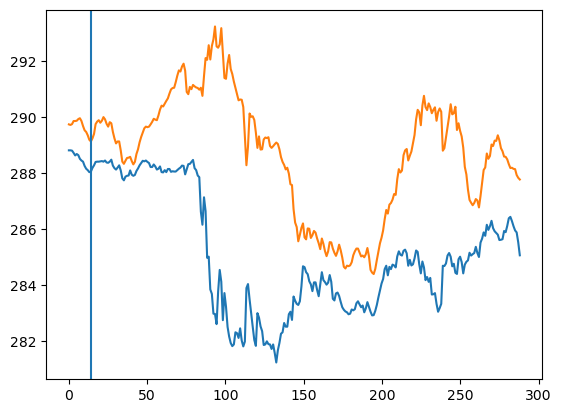

In [ ]:
t_step = np.linspace(0,len(P),len(P))
plt.plot(t_step,T_d_arr)
plt.plot(t_step,T_surf)
#plt.xlim(0,20)
plt.axvline(14)

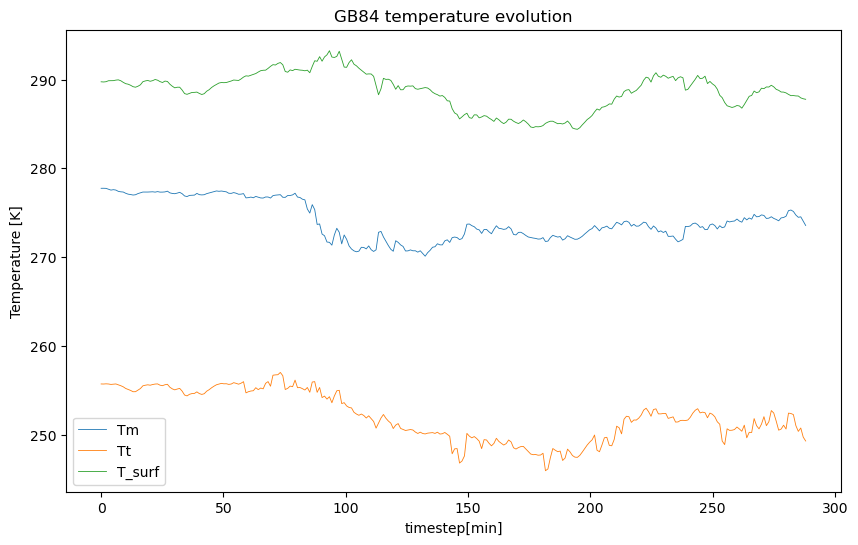

In [ ]:
#temperatures in different heights

plt.figure(figsize=(10,6))
plt.title('GB84 temperature evolution')

plt.plot(t_step,T_m_arr,label='Tm',linewidth=0.6)
plt.plot(t_step,T_t_arr,label='Tt',linewidth=0.6)
plt.plot(t_step,T_surf,label='T_surf',linewidth=0.6)
plt.xlabel('timestep[min]')
plt.ylabel('Temperature [K]')
plt.legend()

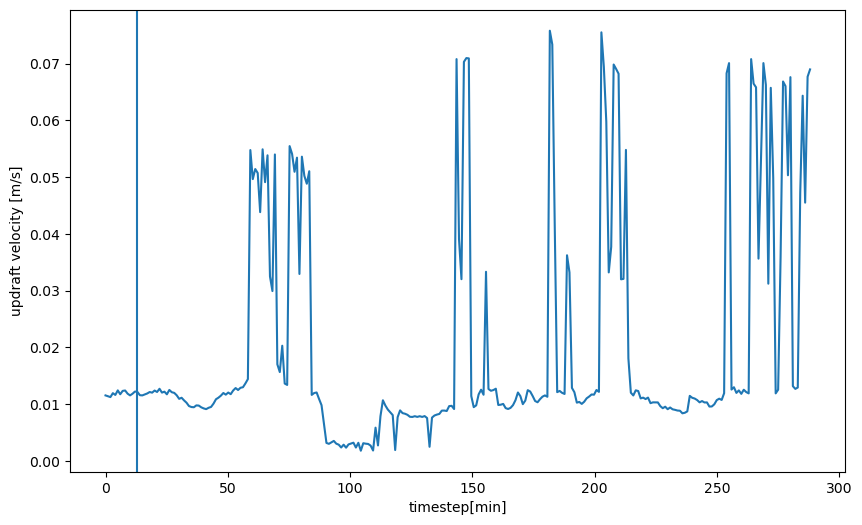

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(t_step,v_arr)
plt.xlabel('timestep[min]')
plt.ylabel('updraft velocity [m/s]')
plt.axvline(13)
#plt.xlim(12,15)

In [ ]:
t_step

array([  0.        ,   1.00348432,   2.00696864,   3.01045296,
         4.01393728,   5.0174216 ,   6.02090592,   7.02439024,
         8.02787456,   9.03135889,  10.03484321,  11.03832753,
        12.04181185,  13.04529617,  14.04878049,  15.05226481,
        16.05574913,  17.05923345,  18.06271777,  19.06620209,
        20.06968641,  21.07317073,  22.07665505,  23.08013937,
        24.08362369,  25.08710801,  26.09059233,  27.09407666,
        28.09756098,  29.1010453 ,  30.10452962,  31.10801394,
        32.11149826,  33.11498258,  34.1184669 ,  35.12195122,
        36.12543554,  37.12891986,  38.13240418,  39.1358885 ,
        40.13937282,  41.14285714,  42.14634146,  43.14982578,
        44.1533101 ,  45.15679443,  46.16027875,  47.16376307,
        48.16724739,  49.17073171,  50.17421603,  51.17770035,
        52.18118467,  53.18466899,  54.18815331,  55.19163763,
        56.19512195,  57.19860627,  58.20209059,  59.20557491,
        60.20905923,  61.21254355,  62.21602787,  63.21

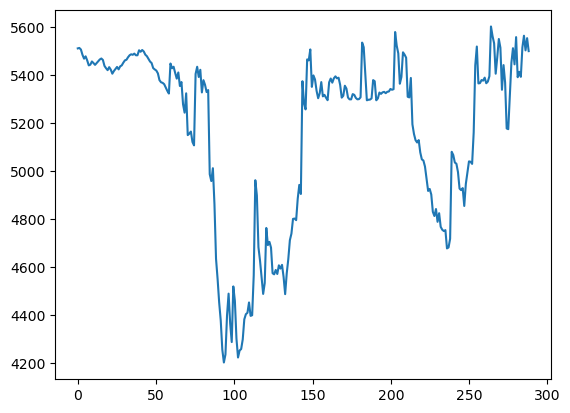

In [71]:
plt.plot(t_step, Z_c_arr)
#plt.plot(t_step, Z_b_arr)

Text(0.5, 1.0, 'Cloud Fluxes')

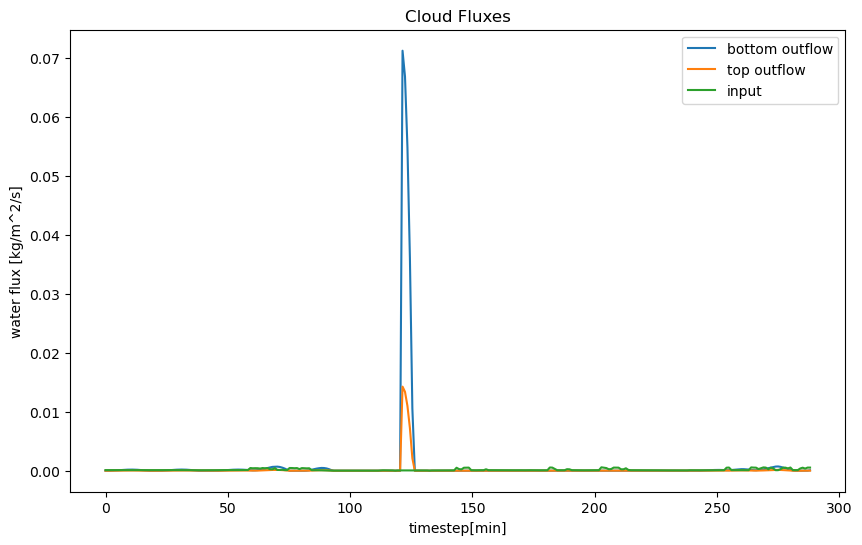

In [ ]:
A = np.zeros(30000)
#for i in range(0,3000):
    #if measurements['rain_rate'].values[7000+i]>0:
        #A[i] = t_step[i]
    #else:
        #A[i] = 0
    

plt.figure(figsize=(10,6))
plt.plot(t_step,O_b_arr,label='bottom outflow')
plt.plot(t_step,O_h_arr,label='top outflow')
plt.plot(t_step,I_arr,label='input')
plt.xlabel('timestep[min]')
plt.ylabel('water flux [kg/m^2/s]')
#plt.vlines(A,0,0.005,alpha=0.1,color='red')
plt.legend()
plt.title('Cloud Fluxes')

In [ ]:
O_b

0.991040470293363

In [ ]:
X[i]*non_dim_numbers(v_updr)[0]/Z_c

array([7.43609522e-05])

In [ ]:
T_t

array([249.29638262])